In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.nflow import NFlowDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.tangent_space_svd import TangentSpacel2SVD
from src.manifolds.euclidean.pullback import PullbackEuclidean
from src.transforms.autoregressive.unit_det_masked_affine_autoregressive import UnitDetMaskedAffineAutoregressiveTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

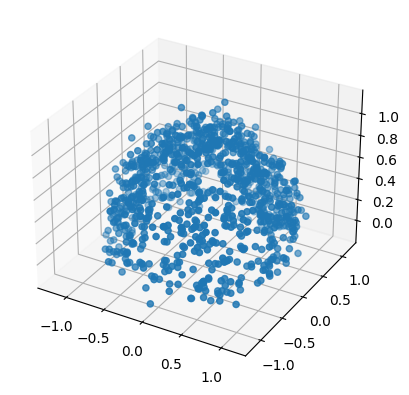

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_train_clean = uniform_sphere_sampling(3, num_samples)
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for _ in range(n_flows):
        transforms_list.append(UnitDetMaskedAffineAutoregressiveTransform(features=dim, hidden_features=16))
        transforms_list.append(transforms.RandomPermutation(features=dim))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [4]:
# Create reconstruction pipeline

class ReconstructionPipeline(nn.Module):
    def __init__(self, forward, diffeo, max_iter, l1_weight):
        super().__init__()
        self.d = diffeo.d
        self.A = forward
        self.phi = diffeo
        self.M = max_iter
        self.gamma = nn.Parameter(1/torch.linalg.svdvals(self.A)[0]**2 * torch.ones(self.M)) # Initialize with 1/\lambda_max(A^TA)
        self.lambd = l1_weight

    def encode(self, y): # Unrolled FB splitting scheme
        N, _ = y.shape
        z = torch.zeros(N,self.d)
        for k in range(self.M):
            # print(self.phi.adjoint_differential_inverse(z, torch.matmul(torch.matmul(self.phi.inverse(z), self.A.t()) - y, self.A)))
            z -= self.gamma[k] * self.phi.adjoint_differential_inverse(z, torch.matmul(torch.matmul(self.phi.inverse(z), self.A.t()) - y, self.A))
            z = torch.sign(z) * torch.max(torch.abs(z) - self.gamma[k] * self.lambd, torch.zeros_like(z))
        return z

    def decode_to_corrupted_data(self, z): # Inverse diffeomorphism conposed with the forward operator
        return torch.matmul(self.phi.inverse(z), self.A.t())
    
    def decode_to_data(self, z): # Inverse diffeomorphism
        return self.phi.inverse(z)

In [5]:
# Initialize the model
dim = 3
n_flows = 4
flow = create_flow_model(dim, n_flows)

forward = torch.eye(dim)
phi = NFlowDiffeomorphism(dim, flow).to(device)
max_iter = 16
l1_weight = 0.1

model = ReconstructionPipeline(forward, phi, max_iter, l1_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [6]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, l1_weight):
    for epoch in range(n_epochs):
        for batch_idx, y in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Encode corrupted data
            z_net = model.encode(y)

            # Decode encoded corrupted data
            y_net = model.decode_to_corrupted_data(z_net)

            # Compute loss
            loss = (1/2 *torch.norm(y_net - y, 2, 1)**2 + l1_weight * torch.abs(z_net).sum(1)).mean()
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [7]:
# Train the model
n_epochs = 100
l1_weight = 0.01
train(model, train_loader, optimizer, n_epochs, l1_weight)

Epoch 1/100, Loss: 0.0273
Epoch 2/100, Loss: 0.0267
Epoch 3/100, Loss: 0.0263
Epoch 4/100, Loss: 0.0260
Epoch 5/100, Loss: 0.0256
Epoch 6/100, Loss: 0.0254
Epoch 7/100, Loss: 0.0253
Epoch 8/100, Loss: 0.0252
Epoch 9/100, Loss: 0.0251
Epoch 10/100, Loss: 0.0250
Epoch 11/100, Loss: 0.0250
Epoch 12/100, Loss: 0.0249
Epoch 13/100, Loss: 0.0248
Epoch 14/100, Loss: 0.0247
Epoch 15/100, Loss: 0.0247
Epoch 16/100, Loss: 0.0246
Epoch 17/100, Loss: 0.0245
Epoch 18/100, Loss: 0.0245
Epoch 19/100, Loss: 0.0244
Epoch 20/100, Loss: 0.0244
Epoch 21/100, Loss: 0.0243
Epoch 22/100, Loss: 0.0243
Epoch 23/100, Loss: 0.0242
Epoch 24/100, Loss: 0.0242
Epoch 25/100, Loss: 0.0242
Epoch 26/100, Loss: 0.0241
Epoch 27/100, Loss: 0.0241
Epoch 28/100, Loss: 0.0241
Epoch 29/100, Loss: 0.0240
Epoch 30/100, Loss: 0.0240
Epoch 31/100, Loss: 0.0240
Epoch 32/100, Loss: 0.0240
Epoch 33/100, Loss: 0.0240
Epoch 34/100, Loss: 0.0240
Epoch 35/100, Loss: 0.0239
Epoch 36/100, Loss: 0.0239
Epoch 37/100, Loss: 0.0239
Epoch 38/1

### Evaluating Geometry ###

In [8]:
# Construct diffeomorphism

# Construct pullback manifold
manifold = PullbackEuclidean(model.phi)

In [9]:
# special points
x0 = torch.tensor([0.,0.,1.]).to(device)
x1 = torch.tensor([0.,-1.,0.]).to(device)

In [10]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

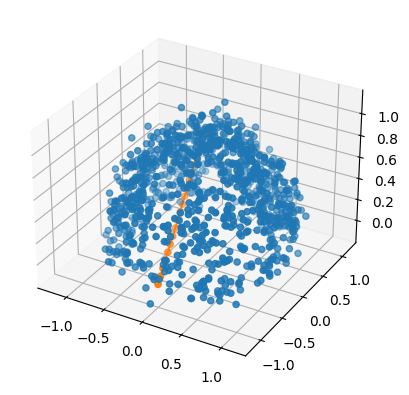

In [11]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [24]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
print(bary)
print(data_train.mean(0))

tensor([0.0148, 0.0653, 0.7220], grad_fn=<SelectBackward0>)
tensor([0.0321, 0.0136, 0.4825])


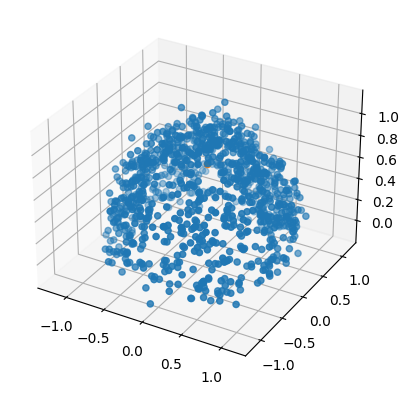

In [22]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [26]:
# construct curvature corrected l2-pga solver
l2_pga_solver = TangentSpacel2SVD(data_train.to(device), manifold, bary)

In [27]:
# compute low rank approximations
l2_pga_solver.solve(2) # compute rank 2 approximation

In [28]:
# compute approximations
approximations = manifold.exp(bary, l2_pga_solver.Xi[2])

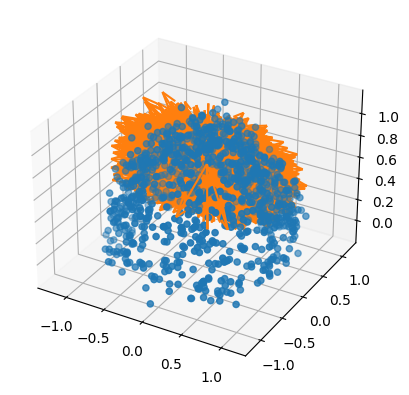

In [33]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 0], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 1], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


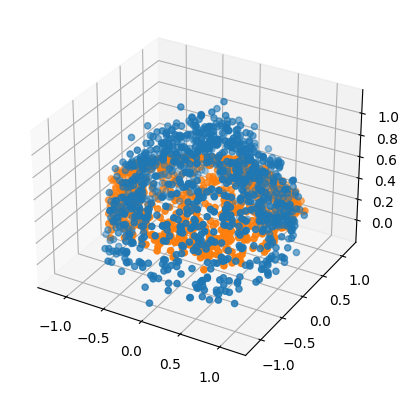

In [30]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(approximations.detach().cpu().numpy()[:,0], approximations.detach().cpu().numpy()[:,1], approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [31]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations)**2,0).sum())

tensor(0.0595, grad_fn=<SumBackward0>)
